In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics.cluster import normalized_mutual_info_score
import pickle

from src.helper_functions.reconstruct_parameters import reconstruct_gamma, compute_tau

In [42]:
import matplotlib.pyplot as plt
from matplotlib import rc
rc('font',**{'family':'serif','serif':['Times']})
rc('text', usetex=True)

colours = [(208/255, 28/255, 139/255),
           (241/255, 182/255, 218/255),
           (184/255, 225/255, 134/255),
           (77/255, 172/255, 38/255)]

colours10 = [(166/255, 206/255, 227/255),
             (31/255, 120/255, 180/255),
             (178/255, 223/255, 138/255),
             (51/255, 160/255, 44/255),
             (251/255, 154/255, 153/255),
             (227/255, 26/255, 28/255),
             (253/255, 191/255, 111/255),
             (255/255, 127/255, 0/255),
             (202/255, 178/255, 214/255),
             (106/255, 61/255, 154/255)]

In [43]:
def load_pickled_file(filepath):
    with open(filepath, 'rb') as file:
        data = pickle.load(file)
    return data

base_path = 'simulations/simulation_5/output'

In [44]:
# layer_groups = []

# phi_w_list = []
# phi_z_list = []
# alpha_rho_list = []
# beta_rho_list = []

# ELBO_full_list = []
layer_groups = {}

phi_w_list = {}
phi_z_list = {}
alpha_rho_list = {}
beta_rho_list = {}

ELBO_full_list = {}

missing_idx = []

for i in range(600):
    try:
        ## SIMULATION PARAMETERS
        # layers
        data = np.load(f'{base_path}/layer_groups/layer_groups_{i}.npy')
        # layer_groups.append(data)
        layer_groups[i] = data
    except FileNotFoundError:
        pass
        
    try:
        ## PARAMETERS
        # phi_w
        data = load_pickled_file(f'{base_path}/phi_w/phi_w_{i}.pkl')
        # phi_w_list.append(data)
        phi_w_list[i] = data
    except FileNotFoundError:
        print(f"Missing phi_w {i}")
        missing_idx.append(i)
    try:
        # phi_u
        data = load_pickled_file(f'{base_path}/phi_z/phi_z_{i}.pkl')
        # phi_z_list.append(data)
        phi_z_list[i] = data
    except FileNotFoundError:
        pass
        
    try:
        # alpha_rho
        data = load_pickled_file(f'{base_path}/alpha_rho/alpha_rho_{i}.pkl')
        # alpha_rho_list.append(data)
        alpha_rho_list[i] = data
    except FileNotFoundError:
        pass
    try:
        # beta_rho
        data = load_pickled_file(f'{base_path}/beta_rho/beta_rho_{i}.pkl')
        # beta_rho_list.append(data)
        beta_rho_list[i] = data
    except FileNotFoundError:
        pass
    try:
        ## ELBO
        # ELBO_full
        data = load_pickled_file(f'{base_path}/ELBO/ELBO_full_{i}.pkl')
        # ELBO_full_list.append(data)
        ELBO_full_list[i] = data
    except FileNotFoundError:
        pass

In [52]:
num_sims = 12
num_layers = 10

ARI_w = []
for sim in range(num_sims):
    if (0 <= sim) & (sim < 4):
        global_groups = np.concatenate(
            (np.repeat(0, 40),
            np.repeat(1, 40),
            np.repeat(2, 20))
        )
    elif (4 <= sim) & (sim < 8):
        global_groups = np.concatenate(
            (np.repeat(0, 100),
            np.repeat(1, 100),
            np.repeat(2, 50))
        )
    else:
        global_groups = np.concatenate(
            (np.repeat(0, 200),
            np.repeat(1, 200),
            np.repeat(2, 100))
        )
    ARI_sim = []
    for i in range(int(sim * 50), int((sim + 1) * 50)):
        if i not in missing_idx:
            ARI_i = normalized_mutual_info_score(phi_w_list[i].argmax(axis=1), global_groups)
            ARI_sim.append(ARI_i)
    ARI_w.append(np.stack(ARI_sim))

ARI_z = []
for sim in range(num_sims):
    ARI_sim = []
    if sim % 4 == 0:
        num_layers = 2
    elif sim % 4 == 1:
        num_layers = 5
    elif sim % 4 == 2:
        num_layers = 10
    else:
        num_layers = 20
        
    for l in range(num_layers):
        ARI_sim_layer = []
        for i in range(int(sim * 50), int((sim + 1) * 50)):
            if i not in missing_idx:
                ARI_sim_layer_i = normalized_mutual_info_score(phi_z_list[i].argmax(axis=2)[l], layer_groups[i][l])
                ARI_sim_layer.append(np.array(ARI_sim_layer_i))
        ARI_sim.append(np.stack(ARI_sim_layer))
    ARI_z.append(ARI_sim)
    
ARI_z_across = [np.array(ARI_z[i]).flatten() for i in range(num_sims)]


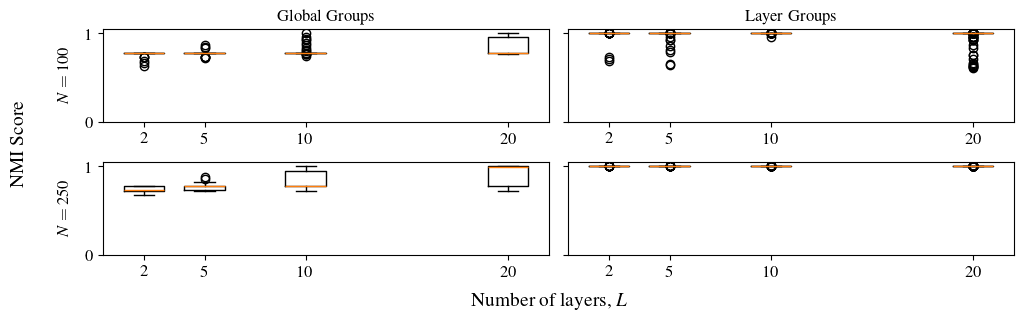

In [80]:
import matplotlib.pyplot as plt

# Create a figure with two subplots (side-by-side)
fig, axes = plt.subplots(2, 2, figsize=(10, 3), sharey=True)  # Share y-axis for better comparison

tick_positions = [2, 5, 10, 20]
labels = ['2', '5', '10','20']

box_width = 2

# First row
axes[0,0].boxplot([ARI_w[i] for i in range(4)], positions=tick_positions, widths=box_width)
axes[0,0].set_ylim(0, 1.05)
axes[0,0].set_xticks(tick_positions)
axes[0,0].set_xticklabels(labels)
axes[0,0].set_ylabel(r'$N=100$', labelpad=10)
axes[0,0].set_title('Global Groups')

axes[0,1].boxplot([ARI_z_across[i] for i in range(4)], positions=tick_positions, widths=box_width)
axes[0,1].set_ylim(0, 1.05)
axes[0,1].set_xticks(tick_positions)
axes[0,1].set_xticklabels(labels)
axes[0,1].set_title('Layer Groups')

# Second row
axes[1,0].boxplot([ARI_w[i] for i in range(4, 8)], positions=tick_positions, widths=box_width)
axes[1,0].set_ylim(0, 1.05)
axes[1,0].set_xticks(tick_positions)
axes[1,0].set_xticklabels(labels)
axes[1,0].set_ylabel(r'$N = 250$', labelpad=10)

axes[1,1].boxplot([ARI_z_across[i] for i in range(4, 8)], positions=tick_positions, widths=box_width)
axes[1,1].set_ylim(0, 1.05)
axes[1,1].set_xticks(tick_positions)
axes[1,1].set_xticklabels(labels)

# # Second row
# axes[2,0].boxplot([ARI_w[i] for i in range(8, 12)])
# axes[2,0].set_ylim(0, 1.05)
# axes[2,0].set_xticklabels(labels)
# axes[2,0].set_ylabel(r'$N = 250$', labelpad=10)

# axes[2,1].boxplot([ARI_z_across[i] for i in range(8, 12)])
# axes[2,1].set_ylim(0, 1.05)
# axes[2,1].set_xticklabels(labels)

# Add row labels
fig.text(-0.01, 0.5, "NMI Score", va='center', ha='center', rotation=90, fontsize=14, fontweight='bold')
fig.text(0.52, -0.02, r"Number of layers, $L$", va='center', ha='center', fontsize=14, fontweight='bold')

for ax in axes.flat:
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.xaxis.label.set_size(12)  # x-label font size
    ax.yaxis.label.set_size(12)  # y-label font size
    ax.title.set_size(12)  # title font size

# Adjust layout and show the figure
plt.tight_layout()

plt.savefig("simulations/simulation_5/plots/NMI_boxplots.pdf", dpi=300, bbox_inches="tight")

plt.show()